In [1]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

In [2]:
# 1. Loading  the dataset
df = pd.read_csv("humaid_processed.csv")

In [3]:
df

,tweet_id,tweet_text,class_label,event,split,event_set,target_label,clean_text,text_length,word_count
0,735891446960623616,RT @DonBradshawNTV: How @MarshallAmpsUK came t...,other_relevant_information,canada_wildfires_2016,train,set1,Situational Awareness,how came to the assistance of fort mcmurray wi...,79,15
1,731202020296818688,Red Cross distributes $30M to Fort McMurray wi...,displaced_people_and_evacuations,canada_wildfires_2016,train,set1,Critical Rescue,red cross distributes 30m to fort mcmurray wil...,69,12
2,733665357236342784,Interesting insights on the shifting communica...,other_relevant_information,canada_wildfires_2016,train,set1,Situational Awareness,interesting insights on the shifting communica...,110,15
3,731963038429929472,RT @globeandmail: Oil sands producers helping ...,rescue_volunteering_or_donation_effort,canada_wildfires_2016,train,set1,Volunteering and Donations,oil sands producers helping workers affected b...,75,11
4,728674838034944001,Ottawa to match Red Cross donations for Fort M...,rescue_volunteering_or_donation_effort,canada_wildfires_2016,train,set1,Volunteering and Donations,ottawa to match red cross donations for fort m...,76,12
...,...,...,...,...,...,...,...,...,...,...
74222,1176533362779013126,@RT_com This is exactly going to happen with #...,not_humanitarian,pakistan_earthquake_2019,test,set2,Irrelevant,this is exactly going to happen with kashmir. ...,256,40
74223,1176504996973764608,May be it is result of betrayal on #KashmirBle...,not_humanitarian,pakistan_earthquake_2019,test,set2,Irrelevant,may be it is result of betrayal on kashmirblee...,60,9
74224,1176467479117410305,Chairman NDMA confirms that 50 people are repo...,injured_or_dead_people,pakistan_earthquake_2019,test,set2,Critical Rescue,chairman ndma confirms that 50 people are repo...,104,18
74225,1176486406803341312,"RT @TariqNaqash: Death toll soars to 8, and of...",injured_or_dead_people,pakistan_earthquake_2019,test,set2,Critical Rescue,"death toll soars to 8, and of them 3 are minor...",114,19


In [4]:
# Ensure there are no missing values in the text column
df['clean_text'] = df['clean_text'].fillna('')

In [5]:
train_df = df[df['split'] == 'train']
test_df = df[df['split'] == 'test']
val_df=df[df['split'] == 'dev']

In [14]:
# Extract features (X) and targets (y)
X_train = train_df['clean_text']
y_train = train_df['target_label']

X_test = test_df['clean_text']
y_test = test_df['target_label']

X_val = val_df['clean_text']
y_val = val_df['target_label']

In [15]:
# 3. Initialize TF-IDF Vectorizer
# Using bigrams and capping at 10,000 features as a good starting baseline
tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1, 2))

# Fit on training data and transform both train and test sets
print("Vectorizing text data...")
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)
X_val_tfidf = tfidf.transform(X_val)

Vectorizing text data...


In [16]:
# 4. Initialize and train the Logistic Regression model
# We use class_weight='balanced' to handle any class imbalances in your dataset
print("Training Logistic Regression model...")
logreg = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
logreg.fit(X_train_tfidf, y_train)

Training Logistic Regression model...


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [17]:
# 5. Predict and evaluate
print("Evaluating model...")
y_pred = logreg.predict(X_test_tfidf)

Evaluating model...


In [18]:
from sklearn.metrics import recall_score,f1_score,confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


Overall Accuracy:  0.7977
Macro F1 Score:    0.7558
Macro Recall:      0.7884

Detailed Classification Report (per class):
                            precision    recall  f1-score   support

           Critical Rescue       0.89      0.91      0.90      2167
                Irrelevant       0.72      0.71      0.72      2902
         Resource Requests       0.41      0.71      0.52       516
     Situational Awareness       0.84      0.78      0.81      4993
Volunteering and Donations       0.85      0.82      0.84      4133

                  accuracy                           0.80     14711
                 macro avg       0.74      0.79      0.76     14711
              weighted avg       0.81      0.80      0.80     14711


 Saved visual confusion matrix as 'confusion_matrix_5_classes.png'


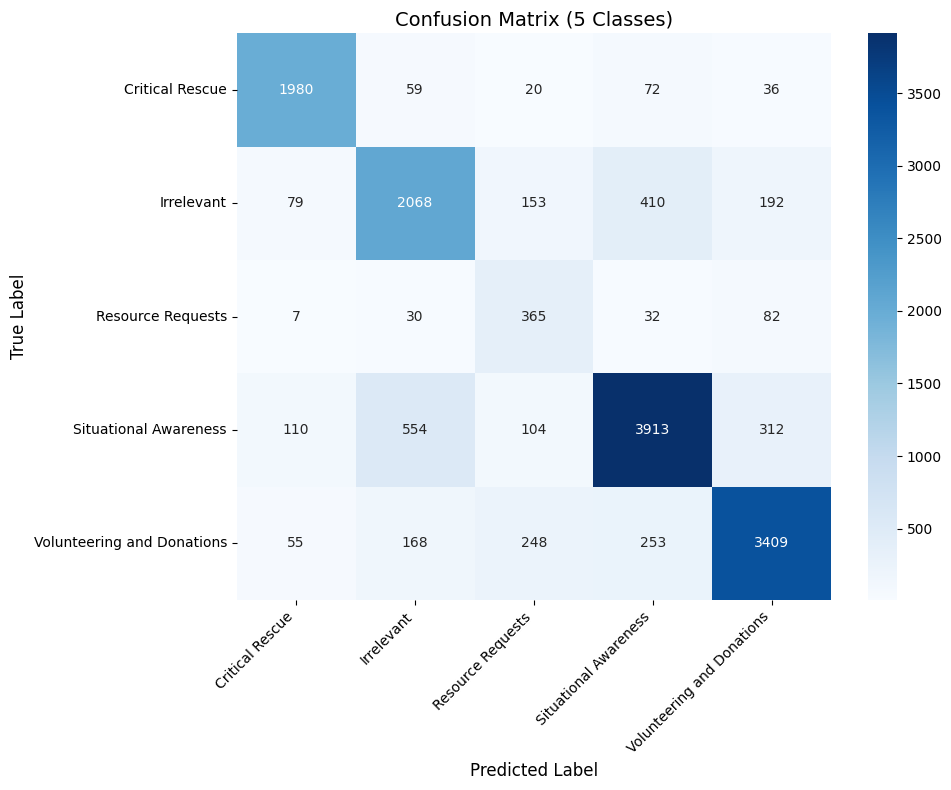

In [19]:
print(f"Overall Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Macro F1 Score:    {f1_score(y_test, y_pred, average='macro'):.4f}")
print(f"Macro Recall:      {recall_score(y_test, y_pred, average='macro'):.4f}")


print("\nDetailed Classification Report (per class):")
print(classification_report(y_test, y_pred))


cm = confusion_matrix(y_test, y_pred, labels=logreg.classes_)

# Plot and save the Confusion Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm, 
    annot=True,          # Show raw numbers
    fmt='d',             # Format as integers
    cmap='Blues',        # Color scheme
    xticklabels=logreg.classes_, 
    yticklabels=logreg.classes_
)

plt.title('Confusion Matrix (5 Classes)', fontsize=14)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.xticks(rotation=45, ha='right')  # Angle labels so they fit nicely
plt.tight_layout()

# Save the plot as a PNG file
plt.savefig('confusion_matrix_5_classes.png', dpi=300)
print("\n Saved visual confusion matrix as 'confusion_matrix_5_classes.png'")


 Saved horizontal bar plots as 'class_metrics_bar_plots.png'


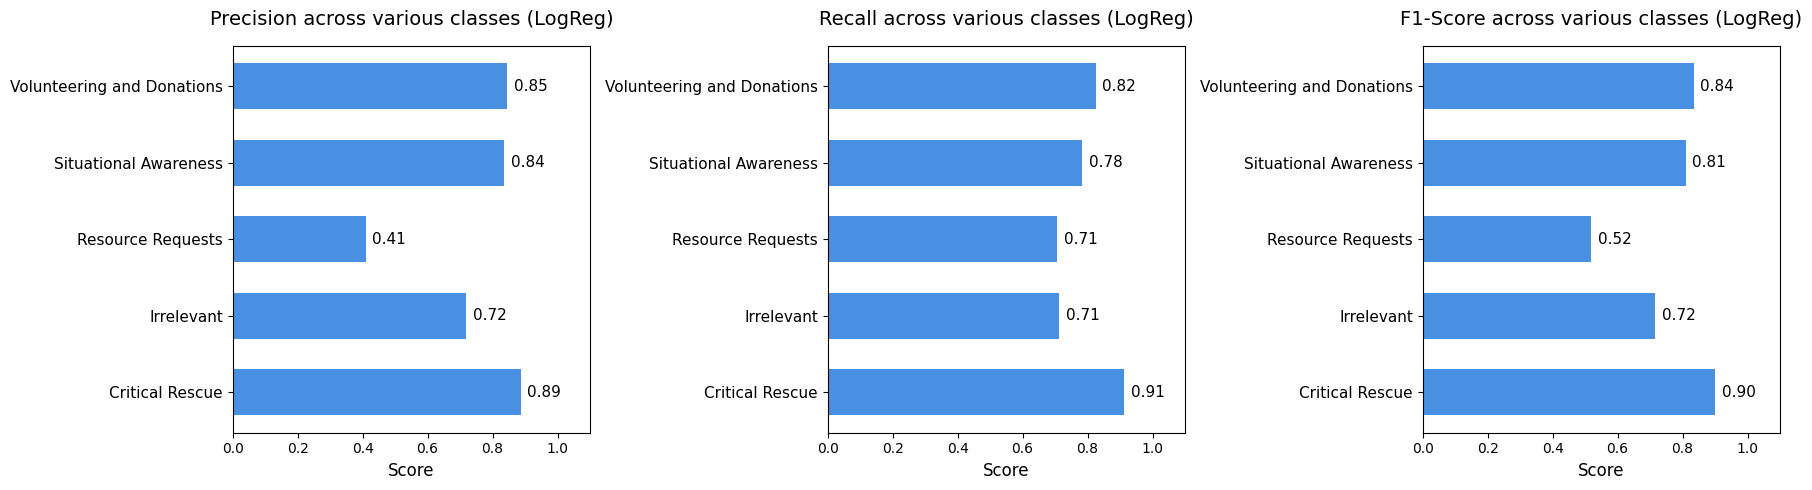

In [20]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Get the classification report as a dictionary to extract the exact numbers
report_dict = classification_report(y_test, y_pred, output_dict=True)
class_names = logreg.classes_

# 2. Extract Precision, Recall, and F1-score for each class
precisions = [report_dict[c]['precision'] for c in class_names]
recalls = [report_dict[c]['recall'] for c in class_names]
f1_scores = [report_dict[c]['f1-score'] for c in class_names]

# 3. Set up the figure with 3 side-by-side subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
y_pos = np.arange(len(class_names))

# Helper function to create the horizontal bar charts
def create_hbar(ax, metric_values, title):
    # Create the bars (using a nice blue color similar to your example)
    bars = ax.barh(y_pos, metric_values, color='#4A90E2', height=0.6)
    
    # Set the ticks and labels
    ax.set_yticks(y_pos)
    ax.set_yticklabels(class_names, fontsize=11)
    ax.set_xlim(0, 1.1)  # Give a little extra room for the text labels
    ax.set_title(title, fontsize=14, pad=15)
    ax.set_xlabel('Score', fontsize=12)
    
    # Add the text annotations at the end of each bar
    for bar in bars:
        width = bar.get_width()
        # Add the text just slightly to the right of the bar
        ax.text(width + 0.02, 
                bar.get_y() + bar.get_height() / 2, 
                f'{width:.2f}', 
                va='center', 
                ha='left', 
                fontsize=11)

# 4. Plot each metric
create_hbar(axes[0], precisions, 'Precision across various classes (LogReg)')
create_hbar(axes[1], recalls, 'Recall across various classes (LogReg)')
create_hbar(axes[2], f1_scores, 'F1-Score across various classes (LogReg)')

# 5. Adjust layout and save the image
plt.tight_layout()
plt.savefig('class_metrics_bar_plots.png', dpi=300, bbox_inches='tight')
print("\n Saved horizontal bar plots as 'class_metrics_bar_plots.png'")

# Display the plot if you are in a Jupyter Notebook
plt.show()